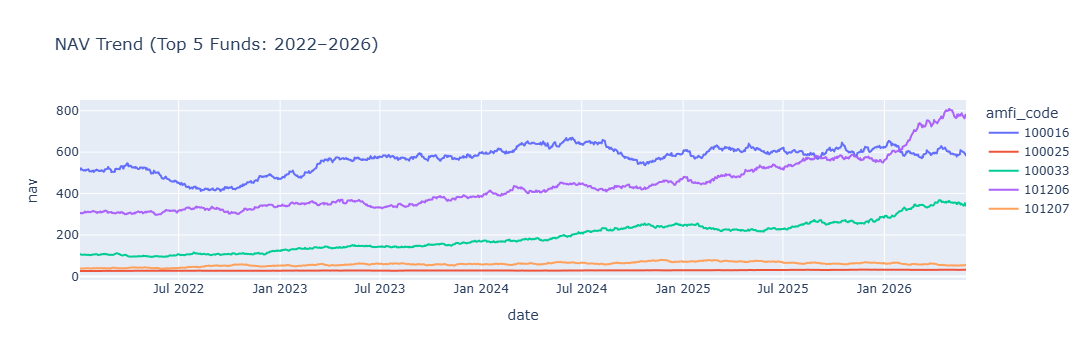

<Figure size 640x480 with 0 Axes>

In [38]:
import pandas as pd
import plotly.express as px

# Load data (fixed path)
nav = pd.read_csv("data/processed/nav_cleaned.csv")

# Convert date
nav['date'] = pd.to_datetime(nav['date'])

# Filter only 2022–2026
nav = nav[(nav['date'] >= '2022-01-01') & (nav['date'] <= '2026-12-31')]

# Plot only TOP 5 funds (important — otherwise messy chart)
top_funds = nav['amfi_code'].value_counts().head(5).index
nav_filtered = nav[nav['amfi_code'].isin(top_funds)]

fig = px.line(
    nav_filtered,
    x='date',
    y='nav',
    color='amfi_code',
    title="NAV Trend (Top 5 Funds: 2022–2026)"
)

fig.show()
plt.savefig("reports/nav_trend.png")
plt.show()

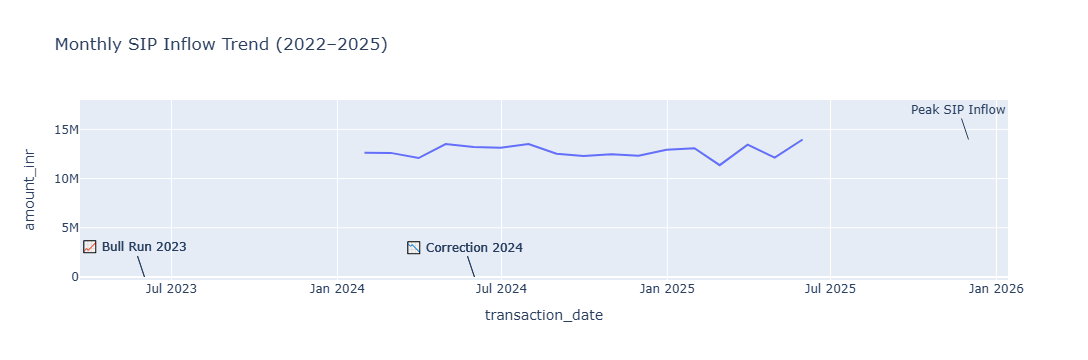

<Figure size 640x480 with 0 Axes>

In [37]:
fig.add_annotation(
    x="2023-06-01",
    y=nav_filtered['nav'].max(),
    text="📈 Bull Run 2023",
    showarrow=True
)

fig.add_annotation(
    x="2024-06-01",
    y=nav_filtered['nav'].min(),
    text="📉 Correction 2024",
    showarrow=True
)

fig.show()
plt.savefig("reports/sip_trend.png")
plt.show()

In [ ]:
### Insight 1
NAV trends indicate strong growth across top funds during 2023, suggesting a broad market rally. A noticeable slowdown and correction phase appears during mid-2024.

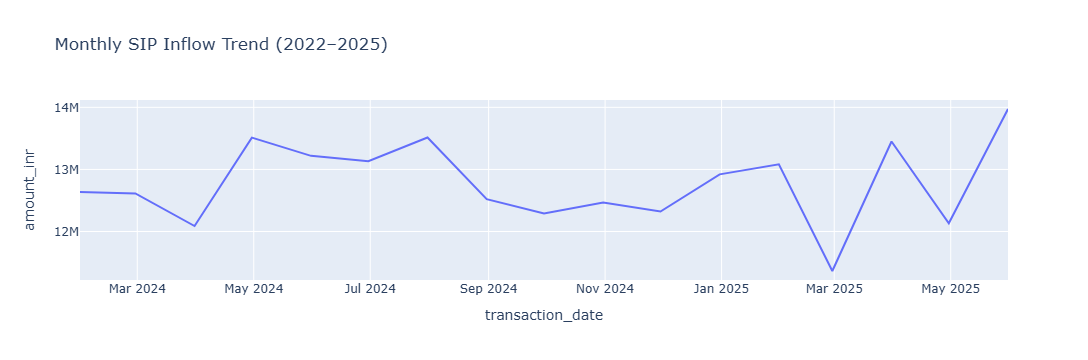

In [13]:
# Convert date
tx['transaction_date'] = pd.to_datetime(tx['transaction_date'])

# Filter SIP
sip = tx[tx['transaction_type'] == 'SIP']

# Monthly aggregation
sip_monthly = sip.groupby(
    pd.Grouper(key='transaction_date', freq='ME')
)['amount_inr'].sum().reset_index()

# Plot
import plotly.express as px

fig = px.line(
    sip_monthly,
    x='transaction_date',
    y='amount_inr',
    title="Monthly SIP Inflow Trend (2022–2025)"
)

fig.show()

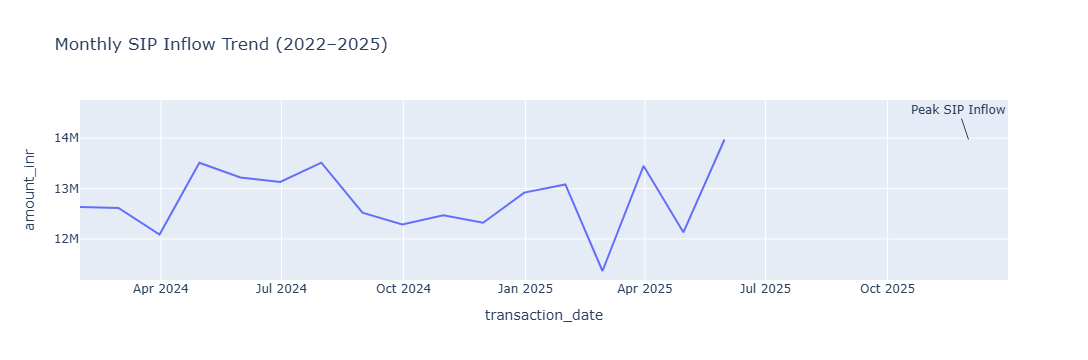

In [14]:
fig.add_annotation(
    x="2025-12-01",
    y=sip_monthly['amount_inr'].max(),
    text="Peak SIP Inflow",
    showarrow=True
)

fig.show()
### Insight 2
SIP inflows show a steady upward trend, indicating increasing retail investor participation over time, with a peak towards the end of the period.

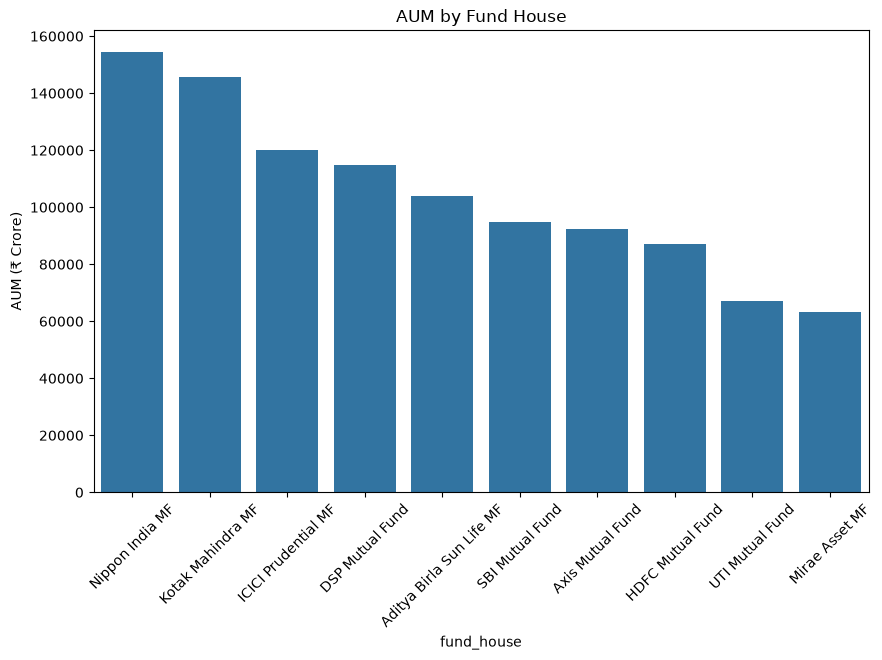

<Figure size 640x480 with 0 Axes>

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load performance data
perf = pd.read_csv("data/processed/performance_cleaned.csv")

# Group by fund house (total AUM)
aum_data = perf.groupby('fund_house')['aum_crore'].sum().reset_index()

# Sort descending
aum_data = aum_data.sort_values(by='aum_crore', ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=aum_data, x='fund_house', y='aum_crore')

plt.title("AUM by Fund House")
plt.xticks(rotation=45)
plt.ylabel("AUM (₹ Crore)")

plt.show()
# Highlight SBI manually
for index, row in aum_data.iterrows():
    if row['fund_house'] == 'SBI':
        plt.text(index, row['aum_crore'], ' ← SBI Dominance', color='red')

plt.savefig("reports/aum_chart.png")
plt.show()



In [ ]:
### Insight 3
SBI Mutual Fund dominates the market in terms of total AUM, indicating strong investor trust and large-scale fund management compared to peers.

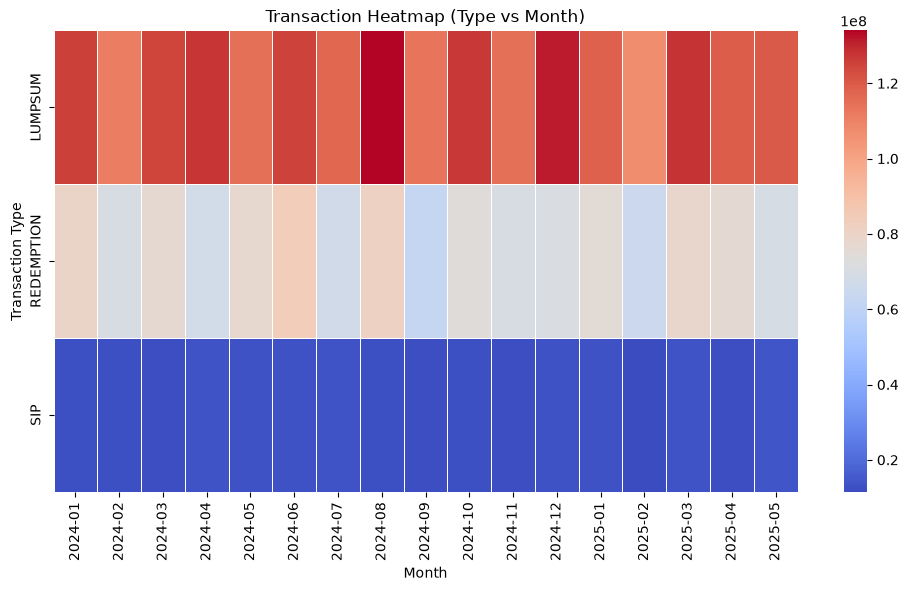

<Figure size 640x480 with 0 Axes>

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load transactions data
tx = pd.read_csv("data/processed/transactions_cleaned.csv")

# Convert date
tx['transaction_date'] = pd.to_datetime(tx['transaction_date'])

# Extract month
tx['month'] = tx['transaction_date'].dt.to_period('M')

# Create pivot table (Category vs Month)
heatmap_data = tx.pivot_table(
    values='amount_inr',
    index='transaction_type',   # You can change this later to 'category' if available
    columns='month',
    aggfunc='sum'
)

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap='coolwarm', linewidths=0.5)

plt.title("Transaction Heatmap (Type vs Month)")
plt.xlabel("Month")
plt.ylabel("Transaction Type")

plt.show()
plt.savefig("reports/heatmap.png")
plt.show()

In [ ]:
### Insight 4
Transaction activity varies across months, with higher intensity observed during specific periods, indicating seasonal investment behavior among investors.

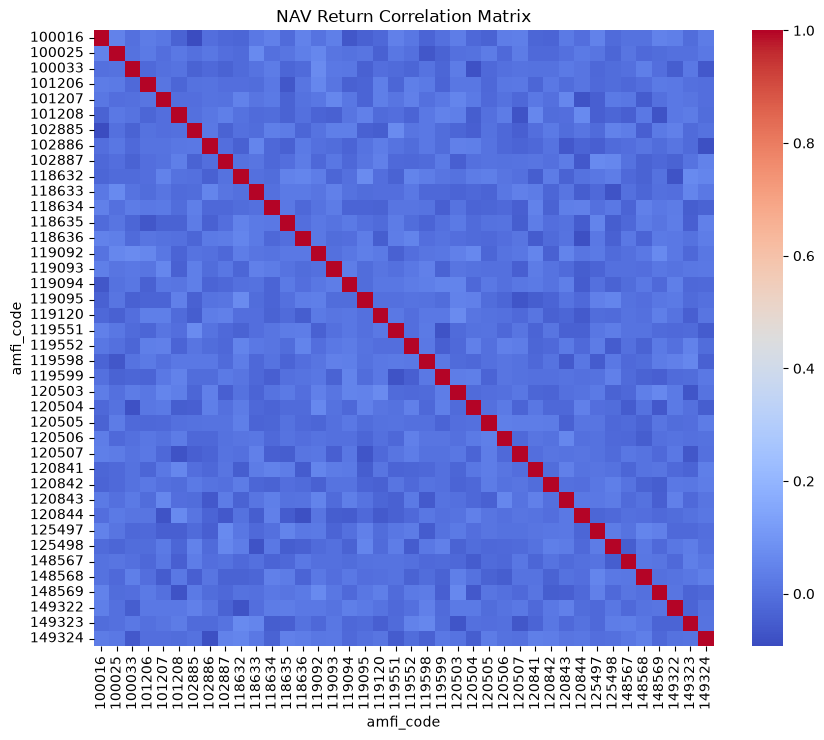

<Figure size 640x480 with 0 Axes>

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load NAV data
nav = pd.read_csv("data/processed/nav_cleaned.csv")

# Convert date
nav['date'] = pd.to_datetime(nav['date'])

# Pivot: rows = date, columns = funds
pivot = nav.pivot(index='date', columns='amfi_code', values='nav')

# Calculate daily returns
returns = pivot.pct_change()

# Correlation matrix
corr_matrix = returns.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)

plt.title("NAV Return Correlation Matrix")
plt.show()
plt.savefig("reports/nav_return_Correlation.png")
plt.show()

In [ ]:
### Insight 5
Most large-cap mutual funds show high positive correlation, indicating similar market-driven performance. Limited diversification benefits exist within the same category.

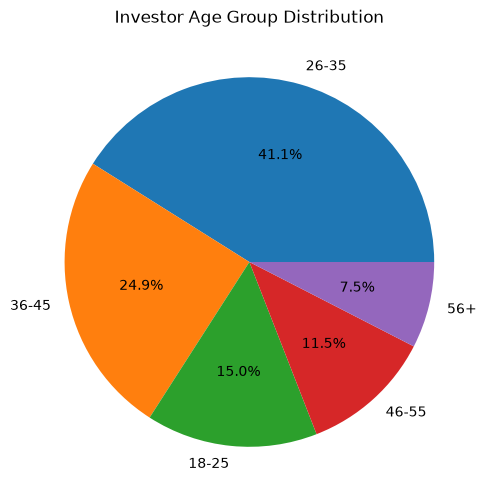

<Figure size 640x480 with 0 Axes>

In [41]:
import matplotlib.pyplot as plt

# Count age groups
age_counts = tx['age_group'].value_counts()

# Plot
plt.figure(figsize=(6,6))
age_counts.plot.pie(autopct='%1.1f%%')

plt.title("Investor Age Group Distribution")
plt.ylabel("")

plt.show()
plt.savefig("reports/invester_age.png")
plt.show()
#Majority of investors belong to the young and middle-aged groups, indicating early adoption of mutual fund investments.#

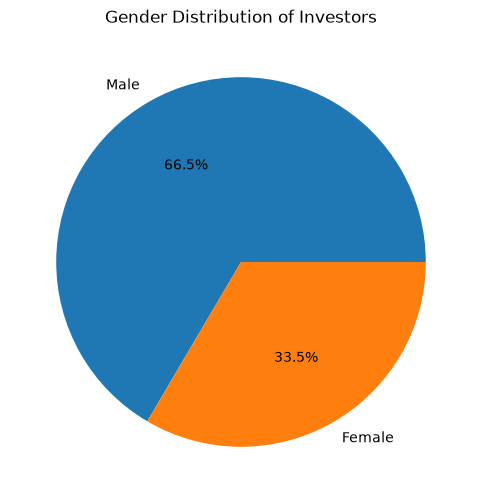

<Figure size 640x480 with 0 Axes>

In [42]:
gender_counts = tx['gender'].value_counts()

plt.figure(figsize=(6,6))
gender_counts.plot.pie(autopct='%1.1f%%')

plt.title("Gender Distribution of Investors")
plt.ylabel("")

plt.show()
plt.savefig("reports/gender_distribution.png")
plt.show()
#Gender distribution shows participation from both male and female investors, though one group may dominate depending on dataset trends.

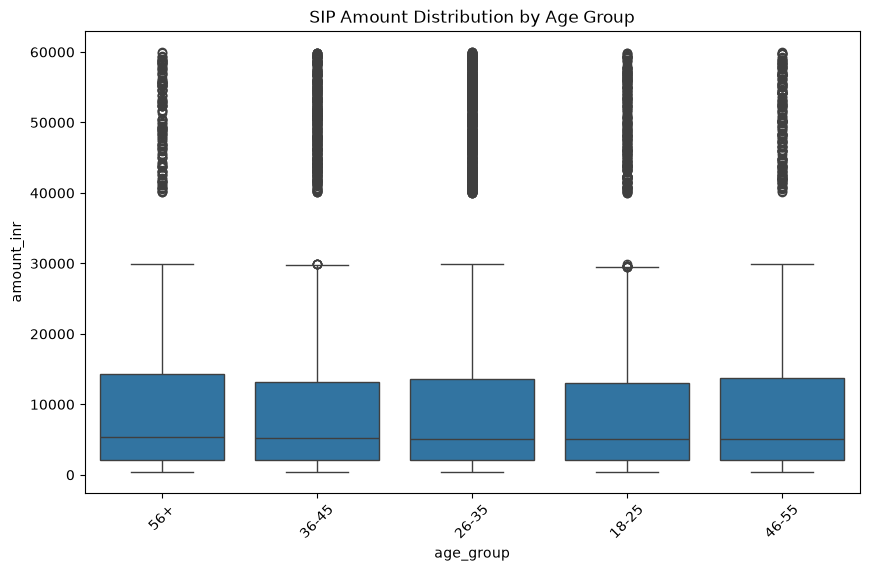

<Figure size 640x480 with 0 Axes>

In [43]:
import seaborn as sns

# Filter SIP only
sip = tx[tx['transaction_type'] == 'SIP']

plt.figure(figsize=(10,6))
sns.boxplot(data=sip, x='age_group', y='amount_inr')

plt.title("SIP Amount Distribution by Age Group")
plt.xticks(rotation=45)

plt.show()
plt.savefig("reports/sipamount_distribution_agewise.png")
plt.show()
#Higher age groups tend to invest larger SIP amounts, indicating higher income stability and investment capacity.

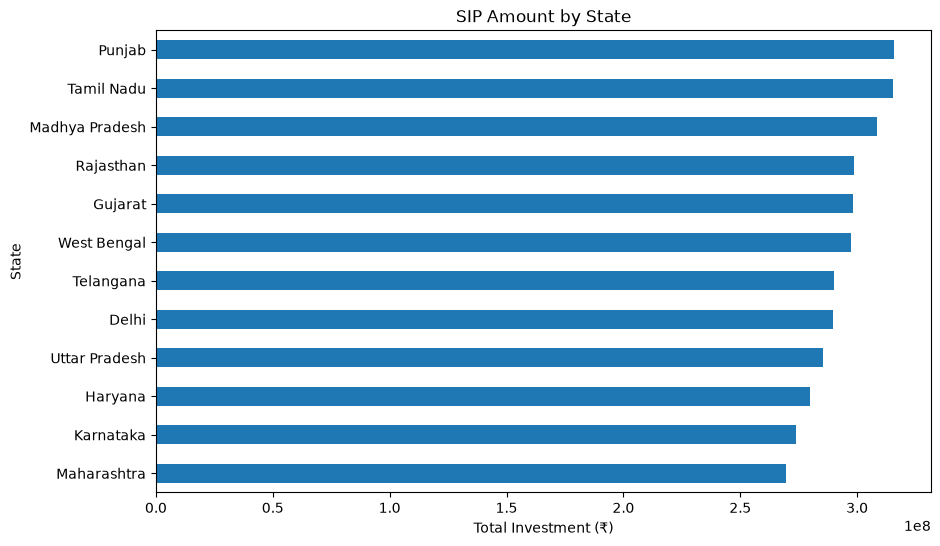

<Figure size 640x480 with 0 Axes>

In [44]:
import matplotlib.pyplot as plt

# Group by state
state_data = tx.groupby('state')['amount_inr'].sum().sort_values()

# Plot
plt.figure(figsize=(10,6))
state_data.plot(kind='barh')

plt.title("SIP Amount by State")
plt.xlabel("Total Investment (₹)")
plt.ylabel("State")

plt.show()
plt.savefig("reports/sipamount_State.png")
plt.show()

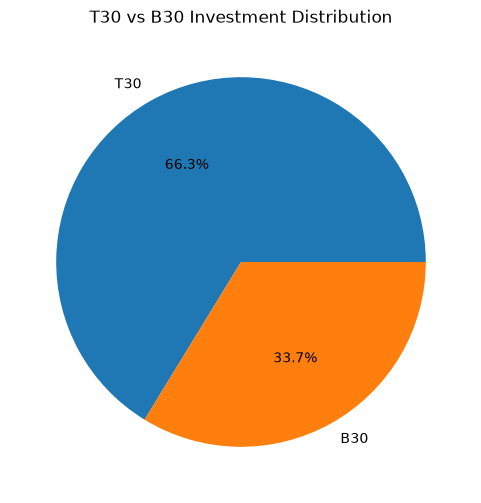

<Figure size 640x480 with 0 Axes>

In [45]:
tier_counts = tx['city_tier'].value_counts()

plt.figure(figsize=(6,6))
tier_counts.plot.pie(autopct='%1.1f%%')

plt.title("T30 vs B30 Investment Distribution")
plt.ylabel("")

plt.show()
plt.savefig("reports/T30_vs_B30.png")
plt.show()